## Outlier

- What is an outlier?
    - Any value that does not belong to the data
        - too large
        - too small
        - too far from mean

In [64]:
import numpy as np
import pandas as pd

data = {
    'ID': [x + 100 for x in range(1, 22)],
    'Name': ['Morozov', 'Alice Smith', 'Bob Jones', 'Charlie John', 'David Lee', 'Eve Martinez', 'Frank Wright', 'Grace Lee', 'Hank Brown', 'Ivy Thompson', 'Jack Davis', 'Athalia', 'Amanda', 'Jacquelina', 'Raphael', 'Rosa Linda', 'Rafeeqa', 'Ameena', 'Raisyaa', 'Hayfa', 'Raisyaa'],
    'Email': ['morosechild@mail', 'alicesmith@mail', None, 'charlie@mail', 'davlee@mail', 'evemartin@mail', 'frank@mail', 'ggrace@mail', None, 'ivytom@mail', 'dav_jac@mail', 'athalia@mail', 'aman_da@mail', 'jac_q@mail', 'Ralph_ael@mail', None, 'feeqa_raff@mail', 'meena@mail', 'syaa_raai@mail', 'hayfa@mail', 'syaa_raai@mail'],
    'Product': ['Camera', None, 'Pc', 'Console', 'Keyboard', 'Pc', 'Keyboard', 'Mouse', 'Cd', 'Pc', 'Headphone', 'Keyboard', None, 'Mouse', 'Pc', 'Smartwatch', 'Tablet', 'Pc', 'Mouse', 'Headphone', 'Mouse'],
    'Quantity': [-3, 1, 1, 1, 1, 1, 2, 1, None, 1, 3, None, 1, 1, 2, 1, None, 1, -2, 2, -2],
    'Price': [41010.99, 987.09, 505.65, 30000.00, 187.90, 199.99, None, 57.00, 90.00, 900.89, 503.77, None, 209.00, 244.56, 99.08, 800.00, 1000.00, 676.00, 761.00, 97.00, 761.00],
    'Delivery': [True, True, True, True, False, True, False, True, True, False, True, False, False, False, False, False, True, True, True, True, True],
    'Date': ['2023-01-01', '2023-01-02', '2023-01-03', '2023-01-04', '04/01/2023', '2023-01-06', '2023-01-07', '9th Jan 2024', '2023-01-09', '2023-01-10', '2023-01-11', '2023-01-12', '2023-01-13', '2023-01-14', '2023-01-15', '2023-01-16', '2023-01-17', '2023-01-18', '20/01/2023', '2023-01-20', '20/01/2023']
}

df = pd.DataFrame(data)
df

,ID,Name,Email,Product,Quantity,Price,Delivery,Date
0,101,Morozov,morosechild@mail,Camera,-3.0,41010.99,True,2023-01-01
1,102,Alice Smith,alicesmith@mail,NaN,1.0,987.09,True,2023-01-02
2,103,Bob Jones,NaN,Pc,1.0,505.65,True,2023-01-03
3,104,Charlie John,charlie@mail,Console,1.0,30000.00,True,2023-01-04
4,105,David Lee,davlee@mail,Keyboard,1.0,187.90,False,04/01/2023
5,106,Eve Martinez,evemartin@mail,Pc,1.0,199.99,True,2023-01-06
6,107,Frank Wright,frank@mail,Keyboard,2.0,NaN,False,2023-01-07
7,108,Grace Lee,ggrace@mail,Mouse,1.0,57.00,True,9th Jan 2024
8,109,Hank Brown,NaN,Cd,NaN,90.00,True,2023-01-09
9,110,Ivy Thompson,ivytom@mail,Pc,1.0,900.89,False,2023-01-10


In [65]:
df.loc[20, 'ID'] = 119

df2 = df.dropna(subset= 'Product').reset_index()
df2.Quantity = abs(df2.Quantity)

df2.Quantity = df2.Quantity.fillna(df2.Quantity.mode()[0])
df2.Email = df2.Email.fillna(df2['Name'].str.lower().str.replace(' ', '_') + '@mail')

display(df2)
df2.info()

,index,ID,Name,Email,Product,Quantity,Price,Delivery,Date
0,0,101,Morozov,morosechild@mail,Camera,3.0,41010.99,True,2023-01-01
1,2,103,Bob Jones,bob_jones@mail,Pc,1.0,505.65,True,2023-01-03
2,3,104,Charlie John,charlie@mail,Console,1.0,30000.00,True,2023-01-04
3,4,105,David Lee,davlee@mail,Keyboard,1.0,187.90,False,04/01/2023
4,5,106,Eve Martinez,evemartin@mail,Pc,1.0,199.99,True,2023-01-06
5,6,107,Frank Wright,frank@mail,Keyboard,2.0,NaN,False,2023-01-07
6,7,108,Grace Lee,ggrace@mail,Mouse,1.0,57.00,True,9th Jan 2024
7,8,109,Hank Brown,hank_brown@mail,Cd,1.0,90.00,True,2023-01-09
8,9,110,Ivy Thompson,ivytom@mail,Pc,1.0,900.89,False,2023-01-10
9,10,111,Jack Davis,dav_jac@mail,Headphone,3.0,503.77,True,2023-01-11


<class 'pandas.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   index     19 non-null     int64  
 1   ID        19 non-null     int64  
 2   Name      19 non-null     str    
 3   Email     19 non-null     str    
 4   Product   19 non-null     str    
 5   Quantity  19 non-null     float64
 6   Price     17 non-null     float64
 7   Delivery  19 non-null     bool   
 8   Date      19 non-null     str    
dtypes: bool(1), float64(2), int64(2), str(4)
memory usage: 1.3 KB


In [43]:
import seaborn as sns

data = pd.Series([18, 20, 20, 20, 23, 25, 30, 30, 25, 30, 35, 40, 68])
data.describe()

count    13.000000
mean     29.538462
std      13.257799
min      18.000000
25%      20.000000
50%      25.000000
75%      30.000000
max      68.000000
dtype: float64

In [44]:
Q = data.quantile([0, 0.25, 0.5, 0.75, 1])
Q

0.00    18.0
0.25    20.0
0.50    25.0
0.75    30.0
1.00    68.0
dtype: float64

In [45]:
Q1 = Q[0.25]
Q3 = Q[0.75]
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print(lower, upper)

data[(data < lower) | (data > upper)]

5.0 45.0


12    68
dtype: int64

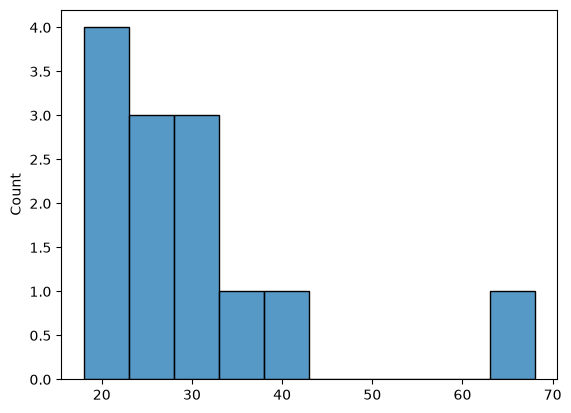

In [46]:
import matplotlib.pyplot as plt
sns.histplot(data, bins= 10)
plt.show()

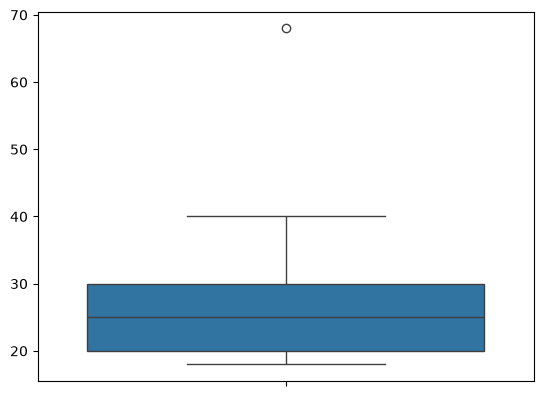

In [47]:
sns.boxplot(data)
plt.show()

<Axes: >

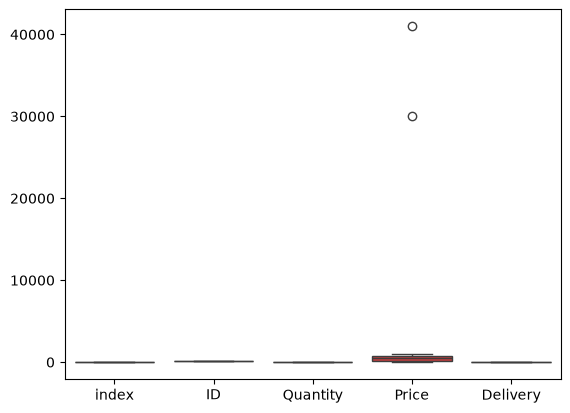

In [66]:
sns.boxplot(df2)

### IQR method of Outlier Removal

Inter Quartile Range:
- IQR = Q3 - Q1

- to define normal data:
    - we decide what the lower bound and upper bound should be
    - anything beyond is outliers

- lower = Q1 - 1.5 * IQR

- upper = Q3 + 1.5 * IQR

In [67]:
# Detect and remove outliers from df2.Price
Q = df2.Price.quantile([0, 0.25, 0.5, 0.75, 1])
Q

0.00       57.00
0.25      187.90
0.50      505.65
0.75      800.00
1.00    41010.99
Name: Price, dtype: float64

In [68]:
Q1 = Q[0.25]
Q3 = Q[0.75]
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print(lower, upper)

outliers = df2.Price[(df2.Price < lower) | (df2.Price > upper)]
outliers

-730.2500000000001 1718.15


0    41010.99
2    30000.00
Name: Price, dtype: float64

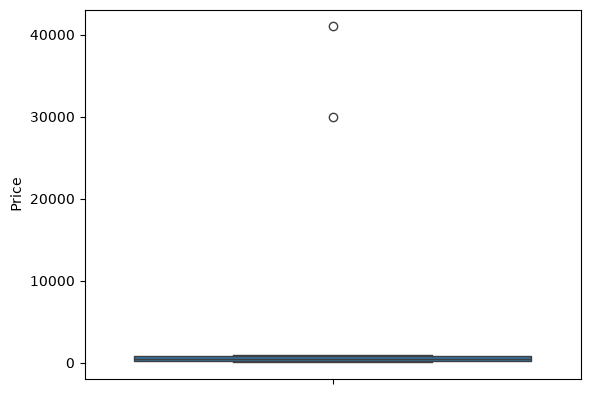

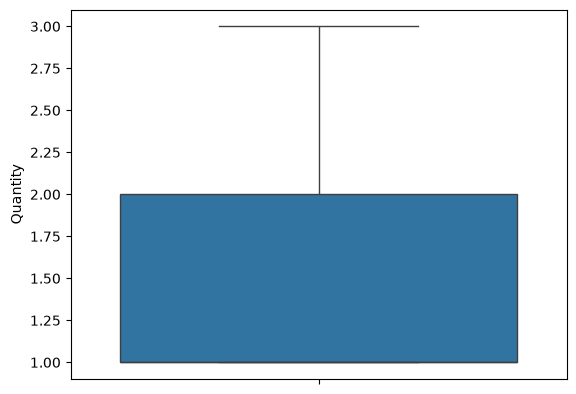

In [70]:
sns.boxplot(data= df2.Price)
plt.show()
sns.boxplot(data= df2.Quantity)
plt.show()

### Date Time - Formats

In [74]:
df2.Date = pd.to_datetime(df2.Date, format= 'mixed')
df2.Date

0    2023-01-01
1    2023-01-03
2    2023-01-04
3    2023-04-01
4    2023-01-06
5    2023-01-07
6    2024-01-09
7    2023-01-09
8    2023-01-10
9    2023-01-11
10   2023-01-12
11   2023-01-14
12   2023-01-15
13   2023-01-16
14   2023-01-17
15   2023-01-18
16   2023-01-20
17   2023-01-20
18   2023-01-20
Name: Date, dtype: datetime64[us]

In [76]:
print(df2.Date.dt.day_name())
print(df2.Date.dt.month_name())
df2.Date.dt.year

0        Sunday
1       Tuesday
2     Wednesday
3      Saturday
4        Friday
5      Saturday
6       Tuesday
7        Monday
8       Tuesday
9     Wednesday
10     Thursday
11     Saturday
12       Sunday
13       Monday
14      Tuesday
15    Wednesday
16       Friday
17       Friday
18       Friday
Name: Date, dtype: str
0     January
1     January
2     January
3       April
4     January
5     January
6     January
7     January
8     January
9     January
10    January
11    January
12    January
13    January
14    January
15    January
16    January
17    January
18    January
Name: Date, dtype: str


0     2023
1     2023
2     2023
3     2023
4     2023
5     2023
6     2024
7     2023
8     2023
9     2023
10    2023
11    2023
12    2023
13    2023
14    2023
15    2023
16    2023
17    2023
18    2023
Name: Date, dtype: int32

### Types of DTypes in pandas?
- object, int64, float, str, 
- object
    - mixed up
- int64
    - number
- float
    - decimal
- bool
    - True False
- datetime - timedelta
    - date and time
- Category
    - categorical data

In [56]:
movie = {
    'Title': ['Inception', 'The Dark Knight', 'Interstellar', 'The Matrix', 'Pulp Fiction'],
    'Year': [2010, 2008, 2014, 1999, 1994],
    'Box_Office_Billions': [0.829, 1.005, 0.677, 0.463, 0.213],
    'Won_Oscar': [True, True, False, False, True],
    'Released': ['2010-07-16', '2008-07-18', '2014-11-07', '1999-03-31', '1994-10-14'],
    'Genre': ['Sci-Fi', 'Action', 'Sci-Fi', 'Sci-Fi', 'Crime']
}

df_movie = pd.DataFrame(movie)

df_movie.Released = pd.to_datetime(df_movie.Released)
df_movie.Genre = df_movie.Genre.astype('category')

df_movie.dtypes

Title                             str
Year                            int64
Box_Office_Billions           float64
Won_Oscar                        bool
Released               datetime64[us]
Genre                        category
dtype: object